In [1]:
from notebooks.consts import NOTEBOOK_PATH

SEEN_MODELS_FOLDER = NOTEBOOK_PATH / 'models' / 'SeenOligoModel'

In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

def get_large_cohort_indices(df, group_cols, min_size=20):
    indices = []
    df_reset = df.reset_index(drop=True)
    for cohort, group in df_reset.groupby(group_cols):
        if len(group) >= min_size:
            indices.append(group.index.values)
    return indices

def evaluate_predictions(preds, y_true, eval_groups):
    if len(y_true) == 0:
        return {"MAE": np.nan, "RMSD": np.nan, "Spearman": np.nan, "Top1_Inhib": np.nan, "Top5_Inhib": np.nan}
    mae = mean_absolute_error(y_true, preds)
    rmsd = np.sqrt(mean_squared_error(y_true, preds))

    spearmans, top_1_medians, top_5_medians = [], [], []
    for idxs in eval_groups:
        t_vals, p_vals = y_true[idxs], preds[idxs]
        if len(t_vals) < 2: continue
        corr, _ = spearmanr(t_vals, p_vals)
        if not np.isnan(corr): spearmans.append(corr)

        n = len(t_vals)
        k1, k5 = max(1, int(n * 0.01)), max(1, int(n * 0.05))

        if k5 > 0: top_5_medians.append(np.median(t_vals[np.argpartition(p_vals, -k5)[-k5:]]))
        if k1 > 0: top_1_medians.append(np.median(t_vals[np.argpartition(p_vals, -k1)[-k1:]]))

    return {
        "MAE": float(mae),
        "RMSD": float(rmsd),
        "Spearman": float(np.nanmedian(spearmans)) if spearmans else np.nan,
        "Top1_Inhib": float(np.nanmedian(top_1_medians)) if top_1_medians else np.nan,
        "Top5_Inhib": float(np.nanmedian(top_5_medians)) if top_5_medians else np.nan
    }

def evaluate_multiple_models_per_cell_line(model_configs, train_df, val_df, test_df, target_col, eval_groups_dict, cell_line_col):
    y_train, y_val, y_test = train_df[target_col].values, val_df[target_col].values, test_df[target_col].values
    all_metrics = []

    print(f"Evaluating {len(model_configs)} configurations across {len(eval_groups_dict)} grouping strategies per cell line...")
    for model_name, config in model_configs.items():
        try:
            if config.get('is_baseline', False):
                baseline_col = config['baseline_col']
                preds_train = train_df[baseline_col].values
                preds_val = val_df[baseline_col].values
                preds_test = test_df[baseline_col].values
                print(f"✅ Evaluated Baseline: '{model_name}'")
            else:
                bst = xgb.Booster()
                bst.load_model(config['path'])
                model_features = bst.feature_names

                dtrain = xgb.DMatrix(train_df[model_features].values, feature_names=model_features)
                dval = xgb.DMatrix(val_df[model_features].values, feature_names=model_features)
                dtest = xgb.DMatrix(test_df[model_features].values, feature_names=model_features)

                preds_train = bst.predict(dtrain)
                preds_val = bst.predict(dval)
                preds_test = bst.predict(dtest)
                print(f"✅ Evaluated XGBoost: '{model_name}'")

            test_split_name = "Test (Leaked)" if config.get('is_all_data', False) else "Test"

            all_cell_lines = pd.concat([train_df[cell_line_col], val_df[cell_line_col], test_df[cell_line_col]]).dropna().unique()

            for cl in all_cell_lines:
                train_mask = (train_df[cell_line_col] == cl).values
                val_mask = (val_df[cell_line_col] == cl).values
                test_mask = (test_df[cell_line_col] == cl).values

                for group_label, group_cols in eval_groups_dict.items():
                    if train_mask.sum() > 0:
                        train_sub = train_df[train_mask].reset_index(drop=True)
                        train_eval_idx = get_large_cohort_indices(train_sub, group_cols)
                        metrics_train = evaluate_predictions(preds_train[train_mask], y_train[train_mask], train_eval_idx)
                        metrics_train.update({"Model": model_name, "Split": "Train", "Grouping": group_label, "Cell_Line": cl})
                        all_metrics.append(metrics_train)

                    if val_mask.sum() > 0:
                        val_sub = val_df[val_mask].reset_index(drop=True)
                        val_eval_idx = get_large_cohort_indices(val_sub, group_cols)
                        metrics_val = evaluate_predictions(preds_val[val_mask], y_val[val_mask], val_eval_idx)
                        metrics_val.update({"Model": model_name, "Split": "Validation", "Grouping": group_label, "Cell_Line": cl})
                        all_metrics.append(metrics_val)

                    if test_mask.sum() > 0:
                        test_sub = test_df[test_mask].reset_index(drop=True)
                        test_eval_idx = get_large_cohort_indices(test_sub, group_cols)
                        metrics_test = evaluate_predictions(preds_test[test_mask], y_test[test_mask], test_eval_idx)
                        metrics_test.update({"Model": model_name, "Split": test_split_name, "Grouping": group_label, "Cell_Line": cl})
                        all_metrics.append(metrics_test)

        except Exception as e:
            print(f"❌ Failed to evaluate '{model_name}': {e}")

    df_results = pd.DataFrame(all_metrics)
    cols = ['Model', 'Split', 'Cell_Line', 'Grouping', 'Spearman', 'Top1_Inhib', 'Top5_Inhib', 'MAE', 'RMSD']
    return df_results[cols]


In [3]:
from notebooks.models.SeenOligoModel.base_model import split_data
from notebooks.models.utility import load_and_validate_final_data
from tauso.data.consts import CANONICAL_GENE, CELL_LINE, INHIBITION

final_data, features = load_and_validate_final_data(version='oligo', load_competition=True)

# Default config
split_config = {
    'col': 'split',
    'train': 'train',
    'val': 'val',
    'test': 'test'
}

train_df, val_df, test_df = split_data(
    final_data,
    features,
    split_col=split_config["col"],
    train_val=split_config["train"],
    val_val=split_config["val"],
    test_val=split_config["test"],
)


In [4]:
COMPETITION = [
    "PFRED_PLS",
    "PFRED_SVM",
    "OW_Overall",
    "OW_Tm",
    "OW_Intra_Oligo",
    "OW_Duplex",
    "sfold_accessibility",
    "miranda_score",
    "miranda_energy",
    "oligo_ai_score",
]

# 1. Dynamically create dictionary entries for all competition/baseline features
MODELS_TO_COMPARE = {
    f"Competition ({col})": {
        "is_baseline": True,
        "baseline_col": col,
        "is_all_data": False
    } for col in COMPETITION
}

# 2. Add your trained XGBoost models to the dictionary
MODELS_TO_COMPARE.update({
    "L2 (Train+Val)": {
        "path": str(SEEN_MODELS_FOLDER / "Model_Oligo_L2_TrainVal.json"),
        "is_all_data": False
    },
    "L2 (Train+Val) [CustomId]": {
        "path": str(SEEN_MODELS_FOLDER / "Model_Oligo_L2_CustomId_TrainVal.json"),
        "is_all_data": False
    },
    "L1 (Train+Val)": {
        "path": str(SEEN_MODELS_FOLDER / "Model_Oligo_L1_TrainVal.json"),
        "is_all_data": False
    },
    "L1 (Train+Val) [CustomId]": {
        "path": str(SEEN_MODELS_FOLDER / "Model_Oligo_L1_CustomId_TrainVal.json"),
        "is_all_data": False
    },
})

EVAL_GROUPS = {
    'Experiment (custom_id)': 'custom_id',
    'Cohort (Gene x Cell Line)': [CANONICAL_GENE, CELL_LINE]
}

# Run Unified Evaluation Per Cell Line
df_comparison_cell_line = evaluate_multiple_models_per_cell_line(
    model_configs=MODELS_TO_COMPARE,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    target_col=INHIBITION,
    eval_groups_dict=EVAL_GROUPS,
    cell_line_col=CELL_LINE
)

print("\n--- Sample of Results ---")
display(df_comparison_cell_line.head())


Evaluating 14 configurations across 2 grouping strategies per cell line...
✅ Evaluated Baseline: 'Competition (PFRED_PLS)'
✅ Evaluated Baseline: 'Competition (PFRED_SVM)'
✅ Evaluated Baseline: 'Competition (OW_Overall)'
✅ Evaluated Baseline: 'Competition (OW_Tm)'
✅ Evaluated Baseline: 'Competition (OW_Intra_Oligo)'
✅ Evaluated Baseline: 'Competition (OW_Duplex)'
✅ Evaluated Baseline: 'Competition (sfold_accessibility)'
✅ Evaluated Baseline: 'Competition (miranda_score)'
✅ Evaluated Baseline: 'Competition (miranda_energy)'
✅ Evaluated Baseline: 'Competition (oligo_ai_score)'
✅ Evaluated XGBoost: 'L2 (Train+Val)'
✅ Evaluated XGBoost: 'L2 (Train+Val) [CustomId]'
✅ Evaluated XGBoost: 'L1 (Train+Val)'
✅ Evaluated XGBoost: 'L1 (Train+Val) [CustomId]'

--- Sample of Results ---


,Model,Split,Cell_Line,Grouping,Spearman,Top1_Inhib,Top5_Inhib,MAE,RMSD
0,Competition (PFRED_PLS),Train,SH-SY5Y,Experiment (custom_id),0.047948,47.0,52.00,45.334793,51.633051
1,Competition (PFRED_PLS),Validation,SH-SY5Y,Experiment (custom_id),0.109135,50.0,41.50,42.767660,47.899370
2,Competition (PFRED_PLS),Test,SH-SY5Y,Experiment (custom_id),0.005187,41.0,47.00,37.778460,46.022046
3,Competition (PFRED_PLS),Train,SH-SY5Y,Cohort (Gene x Cell Line),0.082362,42.0,49.25,45.334793,51.633051
4,Competition (PFRED_PLS),Validation,SH-SY5Y,Cohort (Gene x Cell Line),0.147604,53.0,49.00,42.767660,47.899370


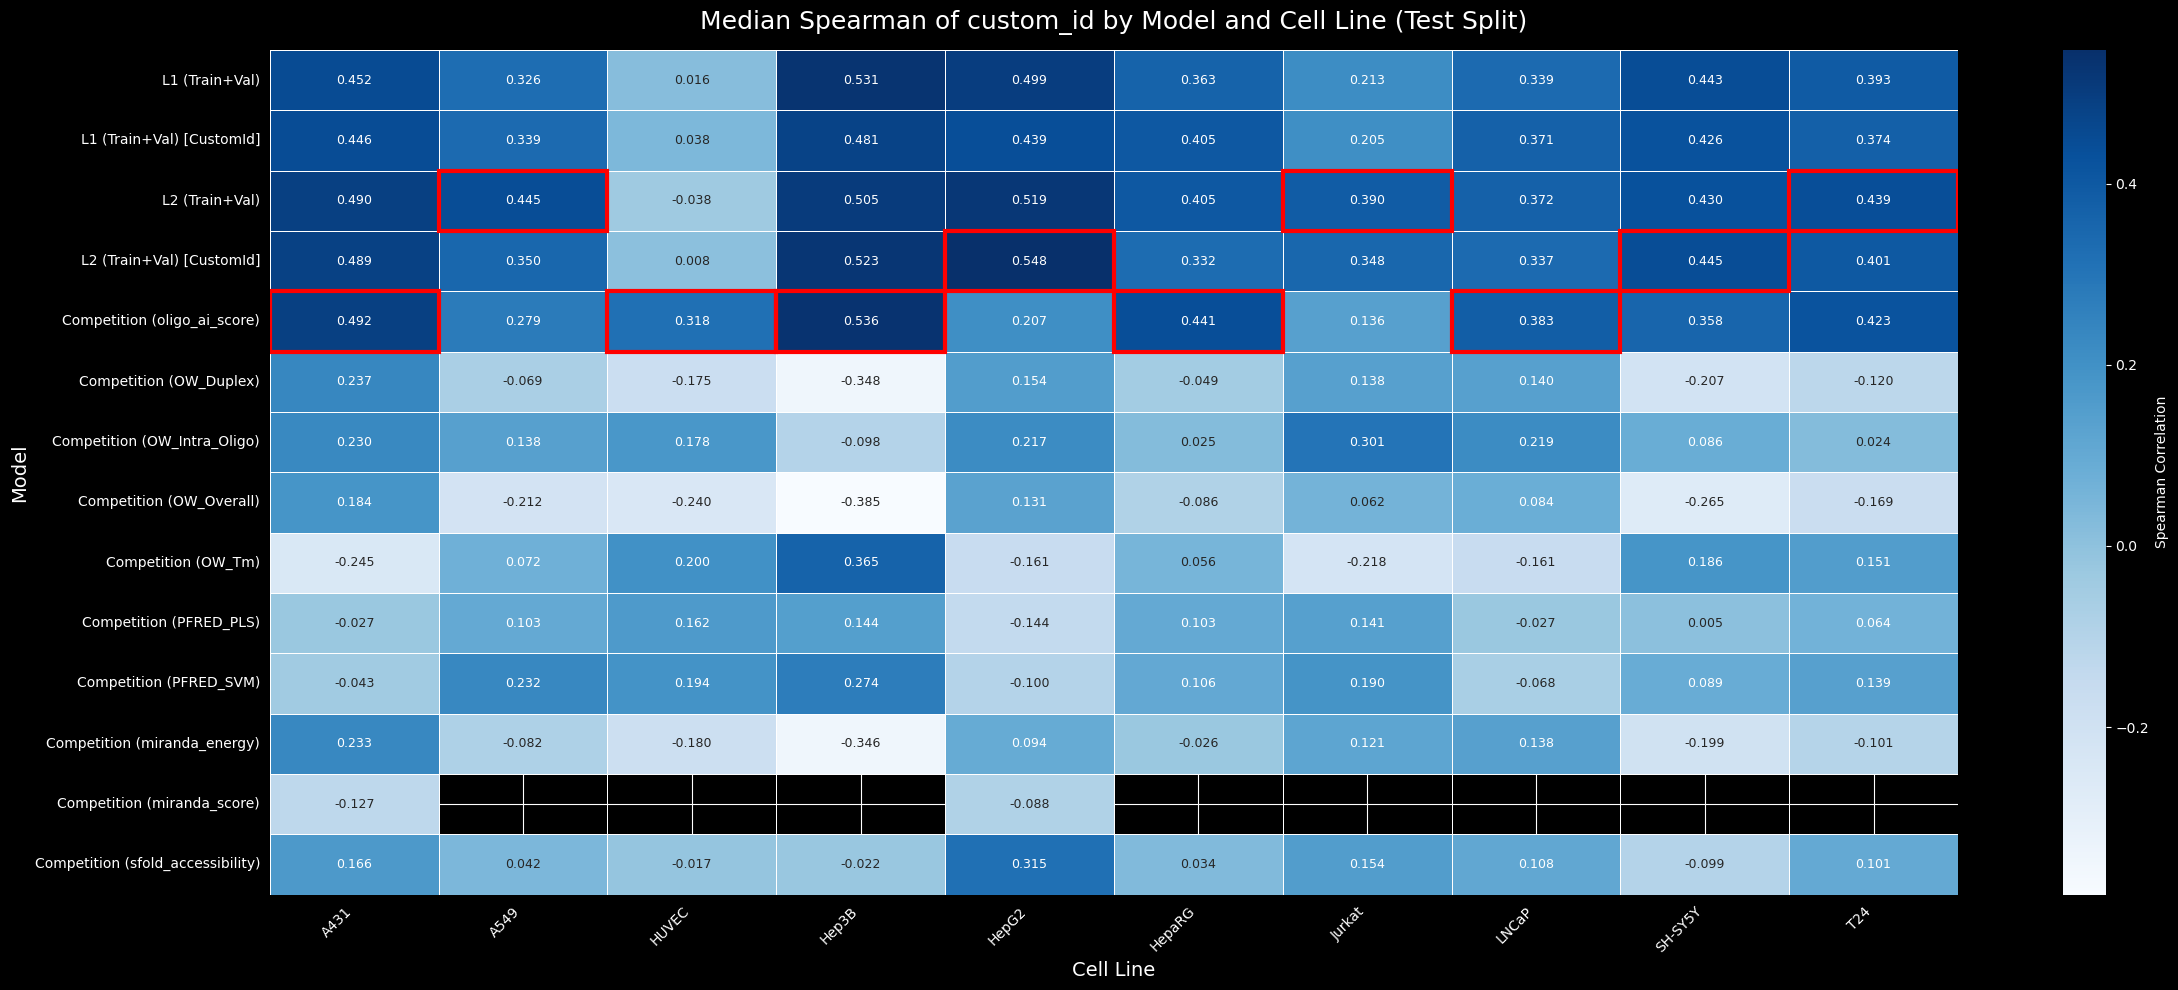

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches
import numpy as np

def plot_improved_heatmap(df):
    # Filter for the relevant grouping and split
    df_plot = df[(df['Grouping'] == 'Experiment (custom_id)') & (df['Split'] == 'Test')]

    # Pivot the dataframe
    heatmap_data = df_plot.pivot(index='Model', columns='Cell_Line', values='Spearman')

    # --- 1. Reorder Rows ---
    priority_models = [
        "L1 (Train+Val)",
        "L1 (Train+Val) [CustomId]",
        "L2 (Train+Val)",
        "L2 (Train+Val) [CustomId]",
        "Competition (oligo_ai_score)"
    ]

    existing_models = heatmap_data.index.tolist()
    top_rows = [m for m in priority_models if m in existing_models]
    remaining_rows = [m for m in existing_models if m not in top_rows]
    heatmap_data = heatmap_data.reindex(top_rows + remaining_rows)

    # --- 2. Create the Heatmap ---
    # Increased width from 16 to 24 to comfortably fit ~34 cell lines
    plt.figure(figsize=(24, 10))

    ax = sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".3f",
        cmap="Blues",
        linewidths=.5,
        cbar_kws={'label': 'Spearman Correlation'},
        annot_kws={"size": 9}  # Slightly smaller text so it all fits
    )

    # --- 3. Highlight the Best Cell per Column (Fixing the NaN issue) ---
    for col_idx, col_name in enumerate(heatmap_data.columns):
        col_data = heatmap_data[col_name]

        # Ensure the column isn't completely empty
        if col_data.notna().any():
            # Use np.nanargmax to safely ignore NaNs!
            max_row_idx = np.nanargmax(col_data.values)

            ax.add_patch(patches.Rectangle(
                (col_idx, max_row_idx),
                1, 1,
                fill=False,
                edgecolor='red',
                lw=3
            ))

    plt.title('Median Spearman of custom_id by Model and Cell Line (Test Split)', fontsize=18, pad=15)
    plt.ylabel('Model', fontsize=14)
    plt.xlabel('Cell Line', fontsize=14)
    plt.xticks(rotation=45, ha='right', fontsize=10)

    plt.tight_layout()
    plt.show()

# Run the plot with your newly generated data
plot_improved_heatmap(df_comparison_cell_line)

In [13]:
from tauso.data.consts import MODIFICATION

def evaluate_multiple_models_per_modification(model_configs, train_df, val_df, test_df, target_col, eval_groups_dict, mod_col):
    y_train, y_val, y_test = train_df[target_col].values, val_df[target_col].values, test_df[target_col].values
    all_metrics = []

    print(f"Evaluating {len(model_configs)} configurations across {len(eval_groups_dict)} grouping strategies per modification...")
    for model_name, config in model_configs.items():
        try:
            if config.get('is_baseline', False):
                baseline_col = config['baseline_col']
                preds_train = train_df[baseline_col].values
                preds_val = val_df[baseline_col].values
                preds_test = test_df[baseline_col].values
            else:
                bst = xgb.Booster()
                bst.load_model(config['path'])
                model_features = bst.feature_names

                dtrain = xgb.DMatrix(train_df[model_features].values, feature_names=model_features)
                dval = xgb.DMatrix(val_df[model_features].values, feature_names=model_features)
                dtest = xgb.DMatrix(test_df[model_features].values, feature_names=model_features)

                preds_train = bst.predict(dtrain)
                preds_val = bst.predict(dval)
                preds_test = bst.predict(dtest)

            test_split_name = "Test (Leaked)" if config.get('is_all_data', False) else "Test"

            # Get unique modifications across all splits
            all_mods = pd.concat([train_df[mod_col], val_df[mod_col], test_df[mod_col]]).dropna().unique()

            for mod in all_mods:
                train_mask = (train_df[mod_col] == mod).values
                val_mask = (val_df[mod_col] == mod).values
                test_mask = (test_df[mod_col] == mod).values

                for group_label, group_cols in eval_groups_dict.items():
                    if train_mask.sum() > 0:
                        train_sub = train_df[train_mask].reset_index(drop=True)
                        train_eval_idx = get_large_cohort_indices(train_sub, group_cols, min_size=1)
                        metrics_train = evaluate_predictions(preds_train[train_mask], y_train[train_mask], train_eval_idx)
                        metrics_train.update({"Model": model_name, "Split": "Train", "Grouping": group_label, "Modification": mod})
                        all_metrics.append(metrics_train)

                    if val_mask.sum() > 0:
                        val_sub = val_df[val_mask].reset_index(drop=True)
                        val_eval_idx = get_large_cohort_indices(val_sub, group_cols, min_size=1)
                        metrics_val = evaluate_predictions(preds_val[val_mask], y_val[val_mask], val_eval_idx)
                        metrics_val.update({"Model": model_name, "Split": "Validation", "Grouping": group_label, "Modification": mod})
                        all_metrics.append(metrics_val)

                    if test_mask.sum() > 0:
                        test_sub = test_df[test_mask].reset_index(drop=True)
                        test_eval_idx = get_large_cohort_indices(test_sub, group_cols, min_size=1)
                        metrics_test = evaluate_predictions(preds_test[test_mask], y_test[test_mask], test_eval_idx)
                        metrics_test.update({"Model": model_name, "Split": test_split_name, "Grouping": group_label, "Modification": mod})
                        all_metrics.append(metrics_test)

        except Exception as e:
            print(f"❌ Failed to evaluate '{model_name}': {e}")

    df_results = pd.DataFrame(all_metrics)
    cols = ['Model', 'Split', 'Modification', 'Grouping', 'Spearman', 'Top1_Inhib', 'Top5_Inhib', 'MAE', 'RMSD']
    return df_results[cols]

# Run the evaluation
df_comparison_mod = evaluate_multiple_models_per_modification(
    model_configs=MODELS_TO_COMPARE,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    target_col=INHIBITION,
    eval_groups_dict=EVAL_GROUPS,
    mod_col=MODIFICATION
)

Evaluating 14 configurations across 2 grouping strategies per modification...


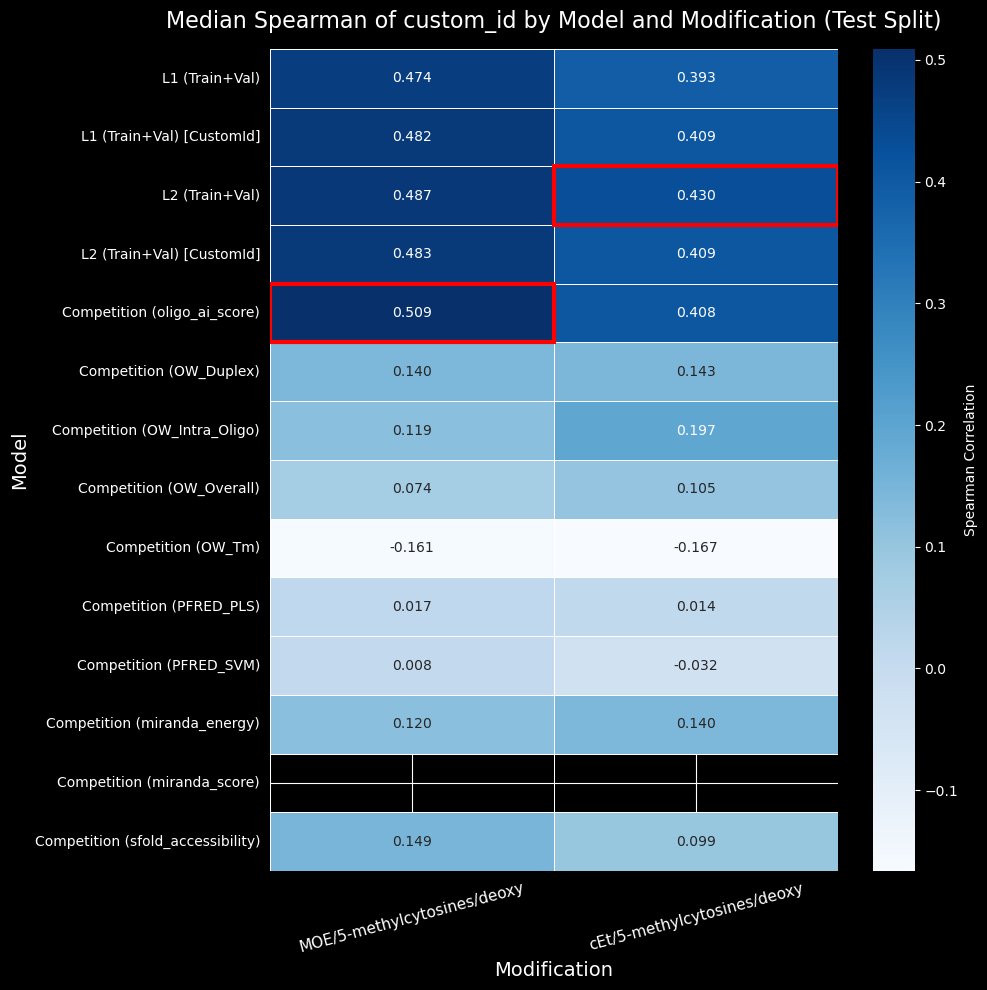

In [14]:
def plot_heatmap_modification(df):
    # Filter for the relevant grouping and split
    df_plot = df[(df['Grouping'] == 'Experiment (custom_id)') & (df['Split'] == 'Test')]

    # Pivot the dataframe using 'Modification' instead of 'Cell_Line'
    heatmap_data = df_plot.pivot(index='Model', columns='Modification', values='Spearman')

    # --- 1. Reorder Rows ---
    priority_models = [
        "L1 (Train+Val)",
        "L1 (Train+Val) [CustomId]",
        "L2 (Train+Val)",
        "L2 (Train+Val) [CustomId]",
        "Competition (oligo_ai_score)"
    ]

    existing_models = heatmap_data.index.tolist()
    top_rows = [m for m in priority_models if m in existing_models]
    remaining_rows = [m for m in existing_models if m not in top_rows]
    heatmap_data = heatmap_data.reindex(top_rows + remaining_rows)

    # --- 2. Create the Heatmap ---
    # Width is reduced to 10 since there are only 2 columns
    plt.figure(figsize=(10, 10))

    ax = sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".3f",
        cmap="Blues",
        linewidths=.5,
        cbar_kws={'label': 'Spearman Correlation'},
        annot_kws={"size": 10}
    )

    # --- 3. Highlight the Best Cell per Column ---
    for col_idx, col_name in enumerate(heatmap_data.columns):
        col_data = heatmap_data[col_name]

        if col_data.notna().any():
            max_row_idx = np.nanargmax(col_data.values)

            ax.add_patch(patches.Rectangle(
                (col_idx, max_row_idx),
                1, 1,
                fill=False,
                edgecolor='red',
                lw=3
            ))

    plt.title('Median Spearman of custom_id by Model and Modification (Test Split)', fontsize=16, pad=15)
    plt.ylabel('Model', fontsize=14)
    plt.xlabel('Modification', fontsize=14)
    plt.xticks(rotation=15, ha='center', fontsize=11)

    plt.tight_layout()
    plt.show()

# Run the plot
plot_heatmap_modification(df_comparison_mod)